<a href="https://colab.research.google.com/github/alwhshalkasr267-design/FinalProject/blob/main/finalproject_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Al-Aqsa University

# Research Title: AI-Based Obstacle Classification for Visually Impaired Assistive Systems Using Convolutional Neural Networks
---

## Development Team & Roles

*  **Yasser Majed Albashyty (ID: 1320224382)** - *Team Leader, System Architecture Engineer & GitHub Management*
*  **Khaled Nael Joma (ID: 1320221356)** - *Data Engineer & Preprocessing Specialist*
*  **Abdul Rahman Essam Radi (ID: 1320230028)** - *Model Training & Optimization Specialist*
*  **Mahmoud Ghalib Aljoraniy (ID: 1320224259)** - *Evaluation & Deployment Specialist*

# **Supervised by:** Dr. Shadia Baroud & miss. Sara Alzamly


##  Dataset Source & Reference

*   **Dataset Name:** Custom Obstacles Dataset for Assistive Navigation
*   **Platform / Source:** Kaggle Data Science Platform
*   **Direct Link to Dataset:** [Click Here to View Dataset on Kaggle](https://www.kaggle.com/)

*(Note: The raw image dataset was downloaded, curated, and structured into categorical subfolders for this project).*
---

##  Dataset Justification & Structural Overview

### 1. Why We Chose This Dataset (Justification):
*   **Real-World Relevance:** It directly captures the most critical indoor and outdoor physical hazards (like potholes, vehicles, and stairs) that threaten the safety of visually impaired pedestrians daily.
*   **High Diversity:** The images feature different lighting conditions, weather settings, and background environments, which helps train our CNN model to be robust and prevent overfitting.

### 2. Dataset Dimensions & Structural Features:
Since this is an **Image Classification Dataset** structured via folder directories (rather than a traditional tabular CSV file), its "Rows and Columns" translate into **Images and Target Classes** as follows:

*   **Total Number of Samples (Rows/Images):** **3,564 Images** in total.
*   **Total Number of Features (Columns/Dimensions):** Each image is a 3-channel color matrix (**RGB**) resized uniformly to $(224 \times 224 \times 3)$ pixels, acting as the structural input vectors.
*   **Target Classes (Labels):** **10 Distinct Categorical Classes** representing environmental objects:
    1. chair
    2. door
    3. fence
    4. garbage_bin
    5. obstacle
    6. plant
    7. pothole
    8. stairs
    9. table
    10. vehicle
---

Mounting Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importing Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import zipfile
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

Zip File Path

In [ ]:
zip_path = '/content/drive/MyDrive/Obstacles_dataset.zip'
extracted_path = '/content/dataset/FinalProject/Obstacles_dataset'

if not os.path.exists(extracted_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_path)
        print("Dataset extracted successfully to the local path.")
else:
        print("Folder already exists.")

Folder already exists.


Data Collection and DataFrame Construction

In [ ]:
folder_path = extracted_path

if len(os.listdir(folder_path)) == 1:
    folder_path = os.path.join(folder_path, os.listdir(folder_path)[0])

classes_names = sorted(os.listdir(folder_path))
print("Dataset Classes: ", classes_names)

Dataset Classes:  ['chair', 'door', 'fence', 'garbage_bin', 'obstacle', 'plant', 'pothole', 'stairs', 'table', 'vehicle']


In [ ]:
i = 1

for folder in sorted(os.listdir(folder_path)):
    full_folder_path = os.path.join(folder_path, folder)

    if os.path.isdir(full_folder_path):
        num_images = len(os.listdir(full_folder_path))

        print(f"{i} Number of [{folder}] Class : {num_images} images")

        i += 1

1 Number of [chair] Class : 407 images
2 Number of [door] Class : 242 images
3 Number of [fence] Class : 179 images
4 Number of [garbage_bin] Class : 175 images
5 Number of [obstacle] Class : 423 images
6 Number of [plant] Class : 139 images
7 Number of [pothole] Class : 706 images
8 Number of [stairs] Class : 504 images
9 Number of [table] Class : 185 images
10 Number of [vehicle] Class : 604 images


In [ ]:
images = []
labels = []

for classes_name in classes_names:
    class_dir = os.path.join(folder_path, classes_name)

    if os.path.isdir(class_dir):

        for file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, file)
            images.append(img_path)
            labels.append(classes_name)

In [ ]:
df = pd.DataFrame({
    "image": images,
    "label": labels
})


df = df.sample(
    frac=1,
    random_state=42
    ).reset_index(drop=True)
print(f"Total images collected: {len(df)}")
df.head(15)

Total images collected: 3564


,image,label
0,/content/dataset/FinalProject/Obstacles_datase...,stairs
1,/content/dataset/FinalProject/Obstacles_datase...,chair
2,/content/dataset/FinalProject/Obstacles_datase...,pothole
3,/content/dataset/FinalProject/Obstacles_datase...,obstacle
4,/content/dataset/FinalProject/Obstacles_datase...,table
5,/content/dataset/FinalProject/Obstacles_datase...,fence
6,/content/dataset/FinalProject/Obstacles_datase...,chair
7,/content/dataset/FinalProject/Obstacles_datase...,chair
8,/content/dataset/FinalProject/Obstacles_datase...,obstacle
9,/content/dataset/FinalProject/Obstacles_datase...,garbage_bin


In [ ]:
bad = []

for p in tqdm(df["image"]):
  try:
    with Image.open(p) as im:
      im.load()
  except:
    bad.append(p)

print("Bad images : ", len(bad))

df = df[~df["image"].isin(bad)].reset_index(drop=True)
print("Remaining images : ", len(df) )

100%|██████████| 3564/3564 [00:07<00:00, 446.25it/s]

Bad images :  0
Remaining images :  3564


Dataset Splitting (Train, Validation, and Test Sets)

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train: ", len(train_df))
print(f"Validation: {len(val_df)}")
print("Test: ", len(test_df))

Train:  2494
Validation: 535
Test:  535


In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

Image Data Generators and Pipeline Buffering

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_it = train_gen.flow_from_dataframe(
    train_df,
    x_col="image",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_it = test_gen.flow_from_dataframe(
    test_df,
    x_col="image",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

val_it = val_gen.flow_from_dataframe(
    val_df,
    x_col="image",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2494 validated image filenames belonging to 10 classes.
Found 535 validated image filenames belonging to 10 classes.
Found 535 validated image filenames belonging to 10 classes.


Computing Class Weights for Handling Imbalanced Data

In [ ]:
from sklearn.utils import class_weight

train_classes = train_it.classes

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)
class_weights_dict = dict(enumerate(class_weights))
print("Computed Class Weights:\n", class_weights_dict)

Computed Class Weights:
 {0: np.float64(0.8750877192982456), 1: np.float64(1.475739644970414), 2: np.float64(1.9952), 3: np.float64(2.0276422764227644), 4: np.float64(0.8425675675675676), 5: np.float64(2.571134020618557), 6: np.float64(0.5048582995951417), 7: np.float64(0.7065155807365439), 8: np.float64(1.9333333333333333), 9: np.float64(0.5895981087470449)}


Custom CNN Architecture Design and Compilation

In [ ]:
model = models.Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(len(classes_names), activation='softmax')
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,641,834 (13.89 MB)

 Trainable params: 3,640,074 (13.89 MB)

 Non-trainable params: 1,760 (6.88 KB)

Configuring Callbacks and Model Training Phase

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

checkpoint_callback = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


In [ ]:
history = model.fit(
    train_it,
    epochs=35,
    validation_data=val_it,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, checkpoint_callback, lr_reducer]
)

Epoch 1/35
78/78 ━━━━━━━━━━━━━━━━━━━━ 63s 620ms/step - accuracy: 0.2799 - loss: 2.2743 - val_accuracy: 0.0673 - val_loss: 5.5566 - learning_rate: 0.0010
Epoch 2/35
78/78 ━━━━━━━━━━━━━━━━━━━━ 38s 487ms/step - accuracy: 0.3721 - loss: 1.8318 - val_accuracy: 0.0673 - val_loss: 6.5218 - learning_rate: 0.0010
Epoch 3/35
78/78 ━━━━━━━━━━━━━━━━━━━━ 37s 470ms/step - accuracy: 0.4366 - loss: 1.6249 - val_accuracy: 0.0692 - val_loss: 5.9571 - learning_rate: 0.0010
Epoch 4/35
78/78 ━━━━━━━━━━━━━━━━━━━━ 38s 481ms/step - accuracy: 0.4864 - loss: 1.4881 - val_accuracy: 0.1271 - val_loss: 3.9495 - learning_rate: 0.0010
Epoch 5/35
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 495ms/step - accuracy: 0.5313 - loss: 1.3743 - val_accuracy: 0.2355 - val_loss: 2.9389 - learning_rate: 0.0010
Epoch 6/35
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 536ms/step - accuracy: 0.5409 - loss: 1.3037 - val_accuracy: 0.5234 - val_loss: 1.5060 - learning_rate: 0.0010
Epoch 7/35
78/78 ━━━━━━━━━━━━━━━━━━━━ 37s 478ms/step - accuracy: 0.5698 - loss: 1.

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('best_model.keras')

Final Model Evaluation, Classification Report, and Confusion Matrix

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.8150 - loss: 0.5345

Final Test Accuracy: 81.50%

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step
Detailed Classification Report:
              precision    recall  f1-score   support

       chair       0.70      0.70      0.70        61
        door       0.86      0.86      0.86        37
       fence       0.71      0.74      0.73        27
 garbage_bin       0.62      0.88      0.73        26
    obstacle       0.88      0.71      0.79        63
       plant       0.95      0.95      0.95        21
     pothole       0.82      0.92      0.87       106
      stairs       0.83      0.70      0.76        76
       table       0.79      0.79      0.79        28
     vehicle       0.90      0.89      0.89        90

    accuracy                           0.81       535
   macro avg       0.81      0.82      0.81       535
weighted avg       0.82      0.81      0.81       535



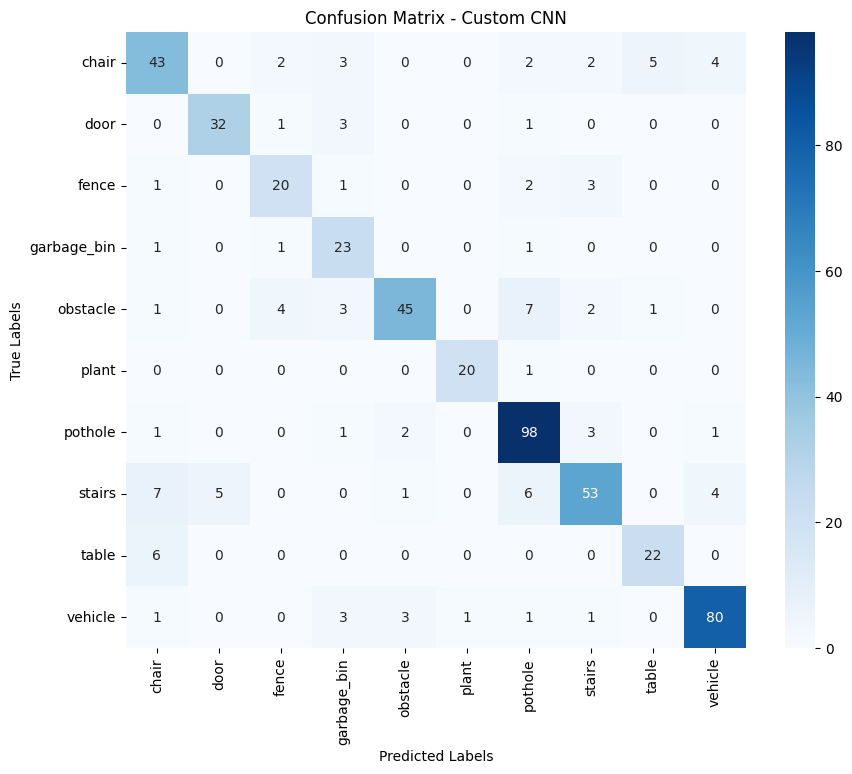

In [ ]:
test_loss, test_acc = model.evaluate(test_it)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%\n")

predictions = model.predict(test_it)
y_pred = np.argmax(predictions, axis=1)
y_true = test_it.classes

print("Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes_names))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Custom CNN')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


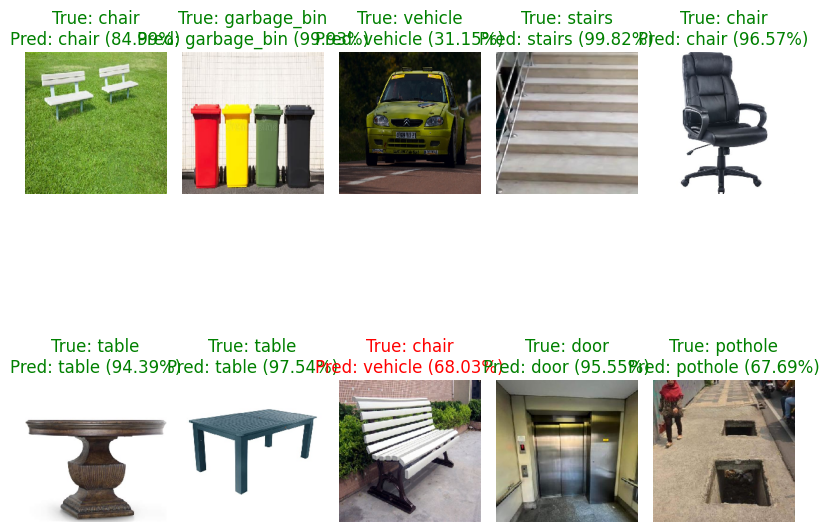

In [ ]:
images, labels = next(test_it)

predictions = model.predict(images)

plt.figure(figsize=(8, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(images[i])
    plt.axis('off')

    true_idx = np.argmax(labels[i])
    true_name = classes_names[true_idx]

    pred_idx = np.argmax(predictions[i])
    pred_name = classes_names[pred_idx]
    confidence = predictions[i][pred_idx] * 100

    color = 'green' if true_name == pred_name else 'red'

    plt.title(f"True: {true_name}\nPred: {pred_name} ({confidence:.2f}%)", color=color, fontsize=12)

plt.tight_layout()
plt.show()

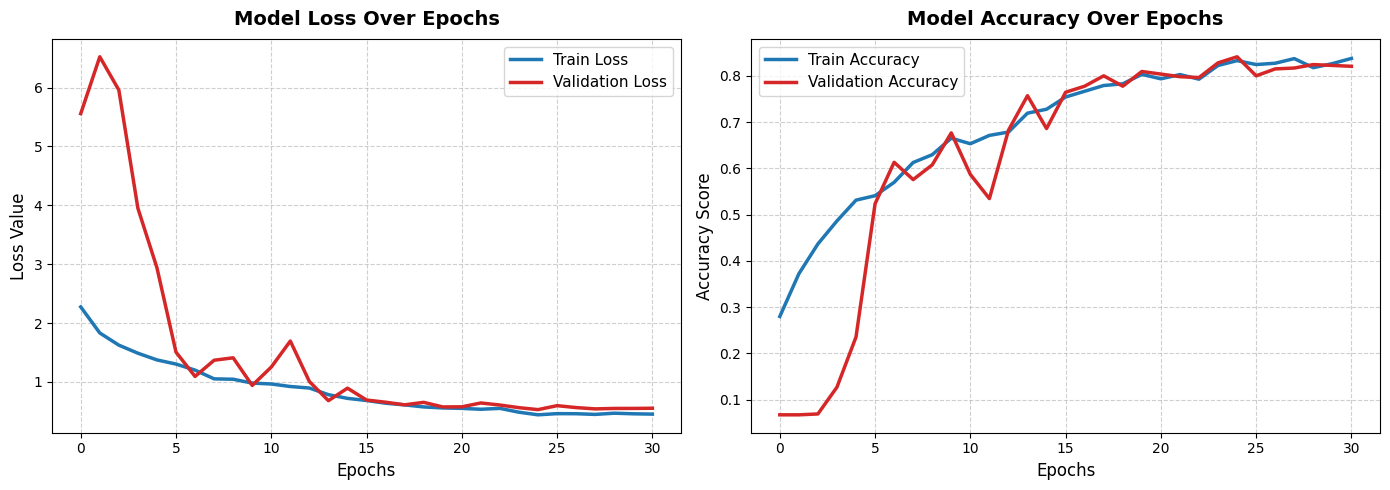

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2.5)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#d62728', linewidth=2.5)
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#1f77b4', linewidth=2.5)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2.5)
plt.title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300)
plt.show()

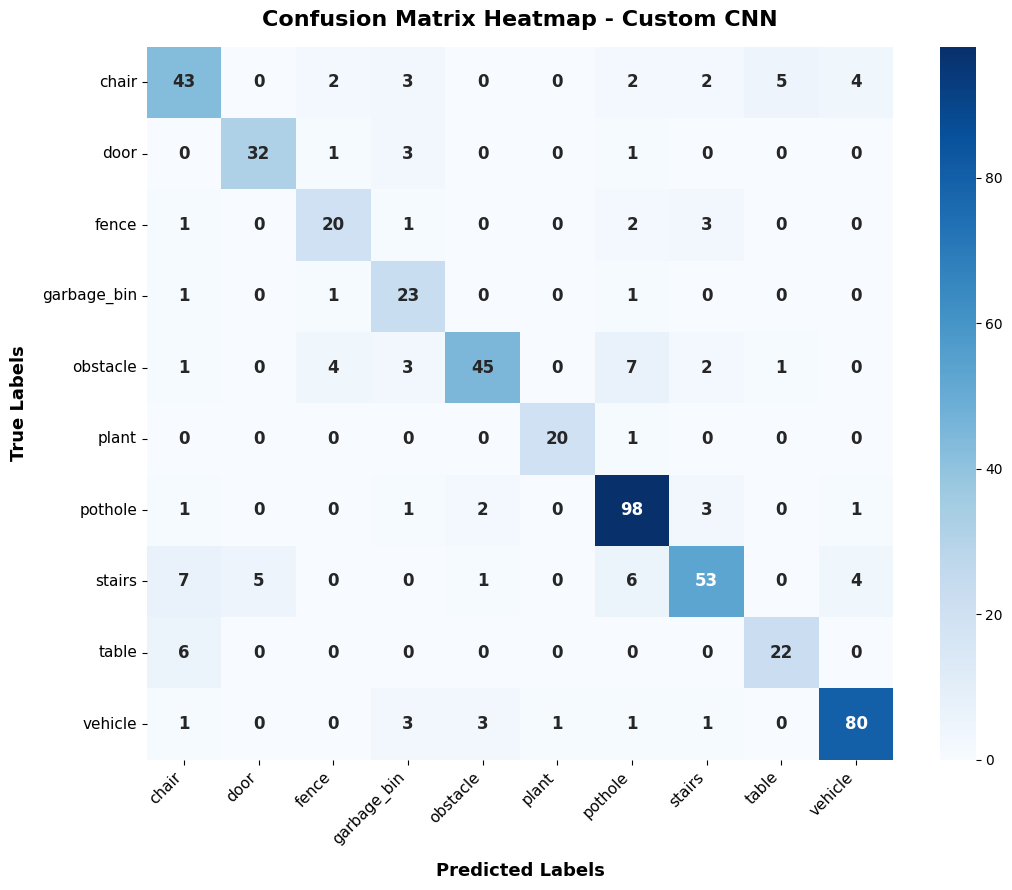

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_true, y_pred)


plt.figure(figsize=(11, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes_names,
    yticklabels=classes_names,
    annot_kws={"size": 12, "weight": "bold"}
)


plt.title('Confusion Matrix Heatmap - Custom CNN', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Labels', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('True Labels', fontsize=13, fontweight='bold', labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)


plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()